# Hospital Readmission Risk Analysis
This notebook analyzes hospital patient records to understand demographic patterns,
diagnosis distribution, treatment costs, and patient outcomes.

Key questions:
• What diagnoses are most common?

• What factors influence treatment costs?

• How long do patients stay in the hospital?

• How do lifestyle factors (smoking, diabetes) relate to outcomes?

In [12]:
#import the libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [3]:
# reading the dataset 
df = pd.read_csv("synthetic_healthcare_data.csv")

In [5]:
df.describe()


,Age,BMI,Cholesterol_Level,Treatment_Cost
count,500.000000,500.000000,500.000000,500.00000
mean,54.140000,28.770400,226.544000,2514.42770
std,21.219069,6.340034,43.667491,1379.49882
min,18.000000,18.000000,151.000000,106.04000
25%,36.000000,23.475000,189.750000,1406.10750
50%,55.000000,28.500000,225.500000,2538.01000
75%,73.000000,34.200000,266.000000,3671.94500
max,90.000000,40.000000,300.000000,4994.04000


In [6]:
df.head()
df.tail()

,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Smoker,Diabetic,Diagnosis,Treatment_Cost,Admission_Date,Discharge_Date,Outcome
495,P496,59,Male,18.3,161 / 77,269,Yes,No,Heart Disease,1675.74,2025-03-29,2025-04-02,Deceases
496,P497,38,Male,19.6,142 / 97,186,Yes,No,Hypertension,2113.33,2025-07-07,2025-07-17,Referred
497,P498,46,Female,28.6,96 / 100,275,No,No,Heart Disease,4121.19,2024-11-21,2024-12-05,Referred
498,P499,47,Female,29.6,162 / 84,201,No,No,Diabetes,1065.24,2025-05-10,2025-05-15,Deceases
499,P500,85,Male,25.0,134 / 74,237,Yes,Yes,Diabetes,422.94,2025-06-10,2025-06-16,Deceases


In [7]:
#Checking for missing values 
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

Patient_ID           0
Age                  0
Gender               0
BMI                  0
Blood_Pressure       0
Cholesterol_Level    0
Smoker               0
Diabetic             0
Diagnosis            0
Treatment_Cost       0
Admission_Date       0
Discharge_Date       0
Outcome              0
dtype: int64

In [13]:
#data cleaning 
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

<Axes: xlabel='Diagnosis', ylabel='count'>

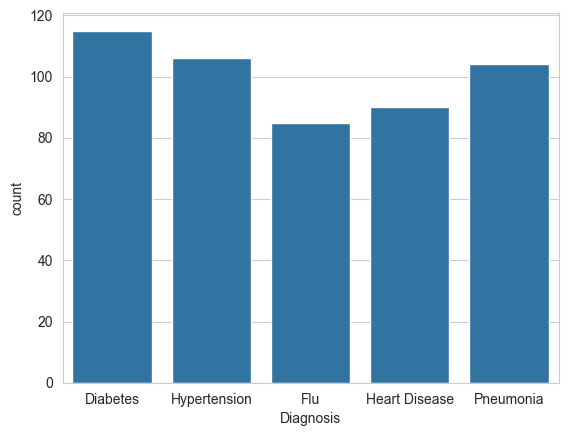

In [14]:
#admissions by the diagnosis 
sns.countplot(x="Diagnosis", data=df)

In [16]:
#length of stay analysis 
df['stay_length'] = df['Discharge_Date'] - df['Admission_Date']

Text(0.5, 1.0, 'Patient Age Distribution')

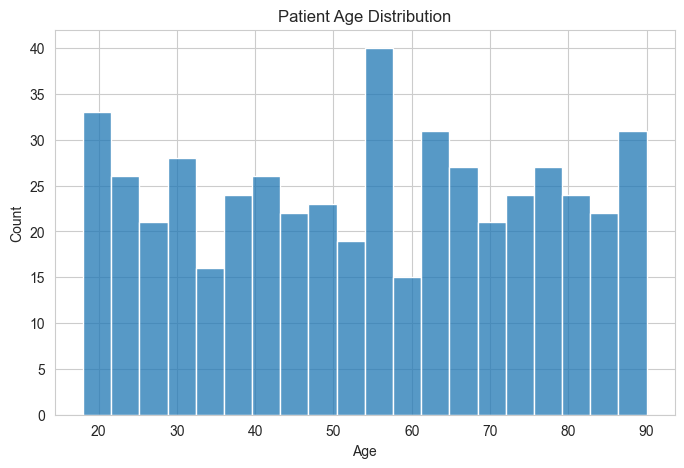

In [17]:
#age distribution 
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Patient Age Distribution")

Text(0.5, 1.0, 'Gender Distribution')

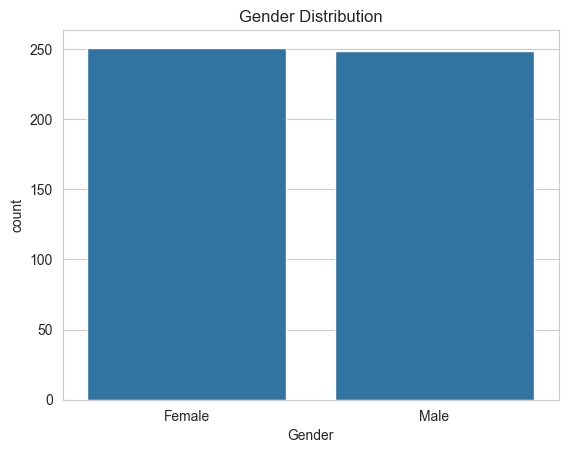

In [18]:
#gender distribution 
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")

LifeStyle risk factors 

<Axes: xlabel='Smoker', ylabel='count'>

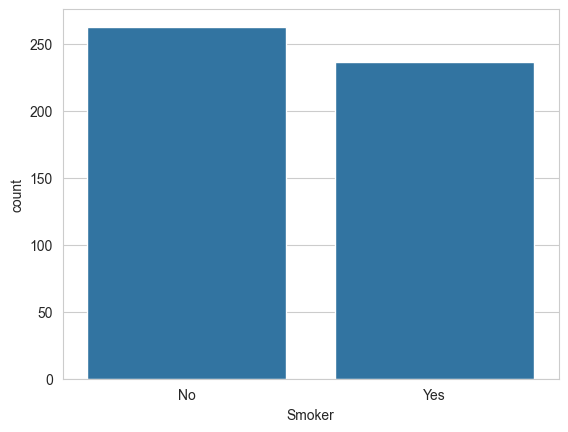

In [19]:
#smoking distribution 
sns.countplot(x="Smoker", data=df)

<Axes: xlabel='Diabetic', ylabel='count'>

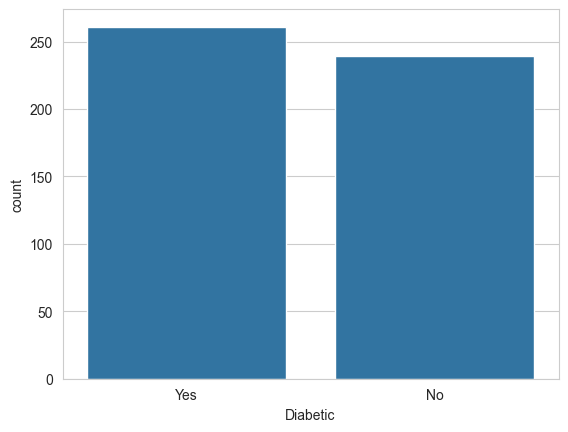

In [20]:
#diabetes distribution 
sns.countplot(x="Diabetic", data=df)

HEALTH METRIC ANALYSIS 

Text(0.5, 1.0, 'BMI Distribution')

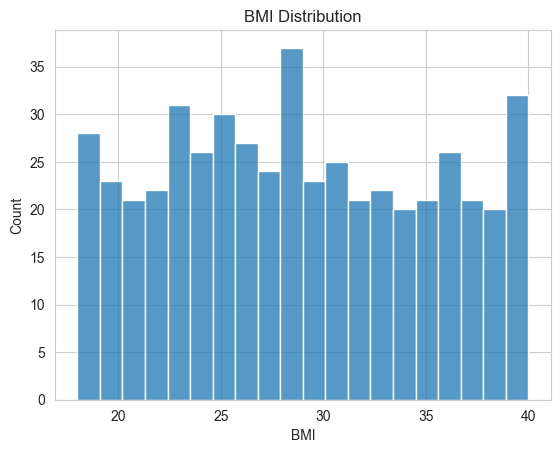

In [21]:
sns.histplot(df["BMI"], bins=20)
plt.title("BMI Distribution")

Text(0.5, 1.0, 'Cholesterol Level Distribution')

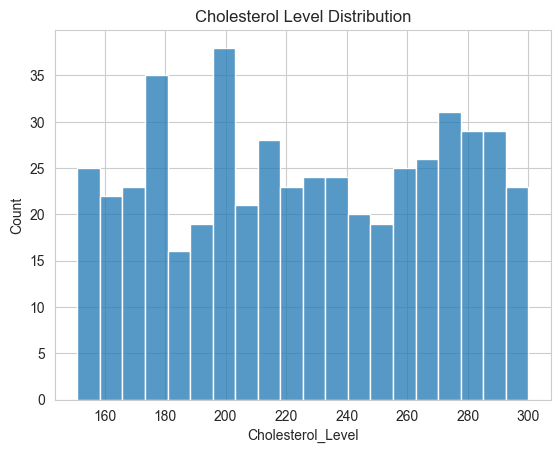

In [22]:
#cholestrol 
sns.histplot(df["Cholesterol_Level"], bins=20)
plt.title("Cholesterol Level Distribution")

Text(0.5, 1.0, 'Treatment Cost Distribution')

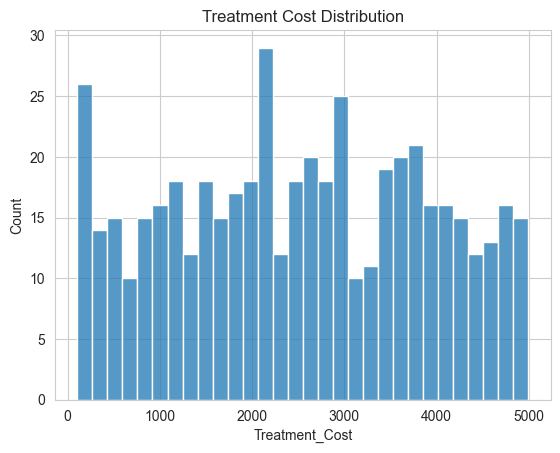

In [24]:
sns.histplot(df["Treatment_Cost"], bins=30)
plt.title("Treatment Cost Distribution")

<Axes: xlabel='Age', ylabel='Treatment_Cost'>

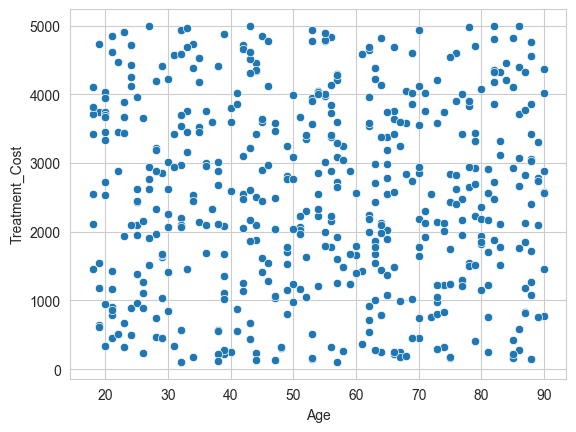

In [25]:
sns.scatterplot(x="Age", y="Treatment_Cost", data=df)

<Axes: xlabel='Outcome', ylabel='count'>

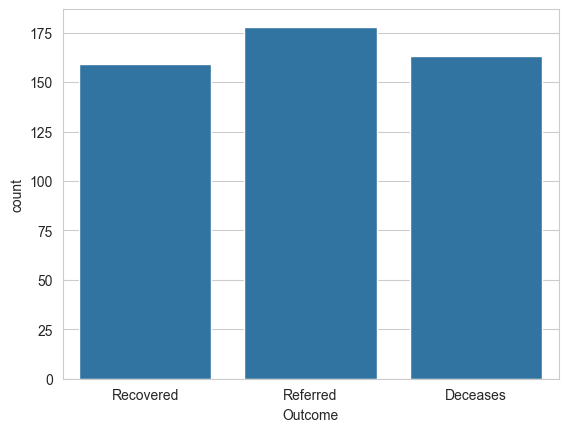

In [26]:
sns.countplot(x="Outcome", data=df)

<Axes: xlabel='Diagnosis', ylabel='count'>

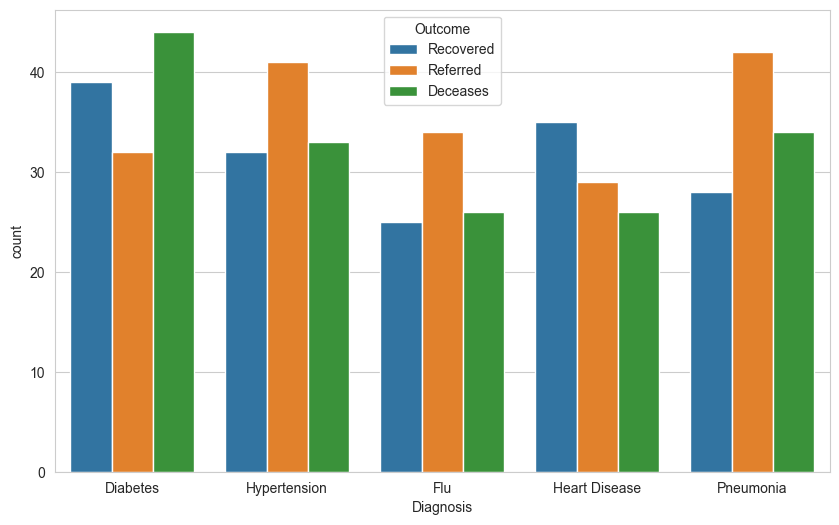

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(x="Diagnosis", hue="Outcome", data=df)

<Axes: xlabel='Smoker', ylabel='count'>

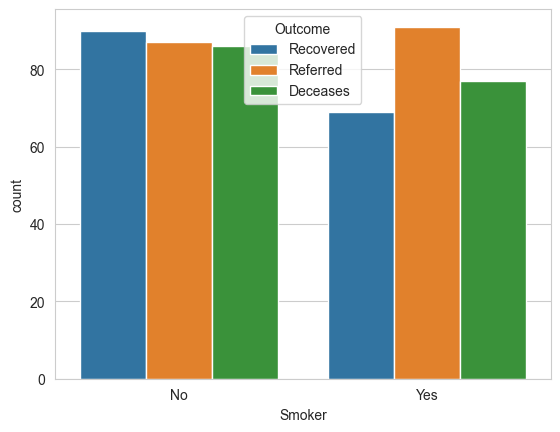

In [28]:
sns.countplot(x="Smoker", hue="Outcome", data=df)

<Axes: xlabel='Diabetic', ylabel='count'>

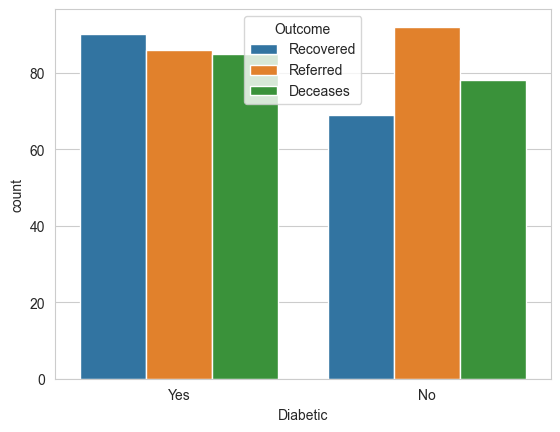

In [29]:
sns.countplot(x="Diabetic", hue="Outcome", data=df)